In [1]:
import pandas as pd, numpy as np, torch, scanpy as sc, matplotlib.pyplot as plt, seaborn as sns
from utils import load_model_state, predict
from sklearn.metrics import roc_auc_score

In [20]:
adata_test = sc.read_h5ad("test.h5ad")

In [21]:
adata_test

AnnData object with n_obs × n_vars = 23399 × 9208
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'split_group'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [22]:
X = adata_test.obsm["X_pca"]

In [23]:
model = load_model_state("result_rna_v2/models/fold0_model.pt", input_dim = X.shape[1])

In [24]:
proba = predict(model, X)

In [25]:
proba

array([0.999833  , 0.99721247, 0.9998498 , ..., 0.99999285, 0.99657613,
       0.99343646], shape=(23399,), dtype=float32)

### Condition proba

In [26]:
pd.crosstab(adata_test.obs["age"], adata_test.obs["genotype"])

genotype,5XFAD,WT
age,,
3M,1569,0
9M,13896,2699
18M,0,5235


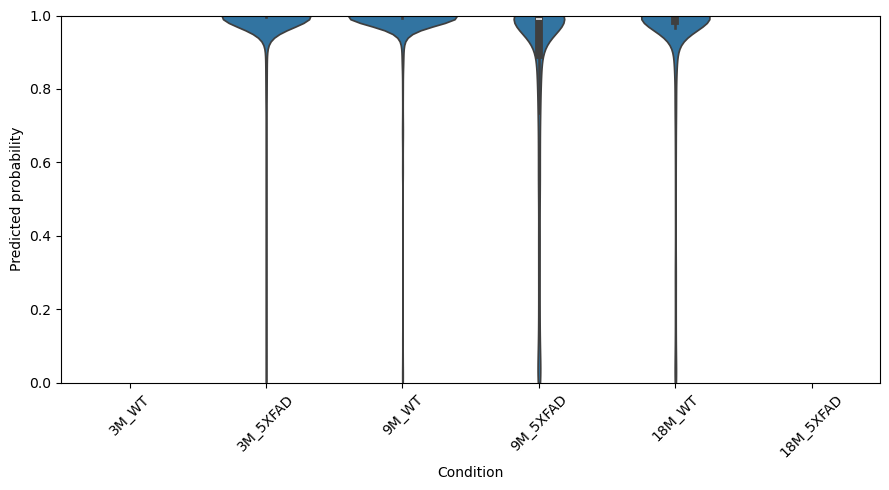

In [27]:
adata_test.obs["probability"] = np.asarray(proba)

df = adata_test.obs[["age", "genotype", "probability"]].copy()

df["condition"] = df["age"].astype(str) + "_" + df["genotype"].astype(str)

condition_order = [
    "3M_WT", "3M_5XFAD",
    "9M_WT", "9M_5XFAD",
    "18M_WT", "18M_5XFAD"
]

plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df,
    x="condition",
    y="probability",
    order=condition_order,
    inner="box",
    cut=0
)

plt.ylabel("Predicted probability")
plt.xlabel("Condition")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("result_rna/micro_proba_all.png", dpi = 300)
plt.show()

### Mouse level proba

/tmp/ipykernel_58914/3919435909.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["mouse_id", "age", "genotype"])["ad_prob"]
/tmp/ipykernel_58914/3919435909.py:19: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


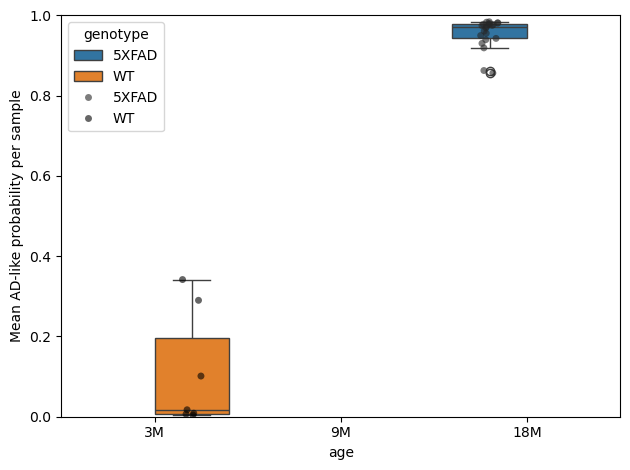

In [19]:
adata_test.obs["ad_prob"] = proba

df = adata_test.obs[["age", "genotype", "mouse_id", "ad_prob"]].copy()

sample_mean = (
    df.groupby(["mouse_id", "age", "genotype"])["ad_prob"]
    .mean()
    .reset_index()
)

sns.boxplot(
    data=sample_mean,
    x="age",
    y="ad_prob",
    hue="genotype",
    order=["3M", "9M", "18M"]
)

sns.stripplot(
    data=sample_mean,
    x="age",
    y="ad_prob",
    hue="genotype",
    order=["3M", "9M", "18M"],
    dodge=True,
    color="black",
    alpha=0.6
)

plt.ylabel("Mean AD-like probability per sample")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("result_rna/micro_donor_proba_all.png", dpi = 300)
plt.show()